<a href="https://colab.research.google.com/github/AnnaPaulaFigueiredo/data_master/blob/main/02_01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [ ]:
import warnings
import shutil
import pandas as pd
import plotly.figure_factory as ff
from google.colab import drive
from pyspark.sql import functions as F
from pyspark.sql import DataFrame
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd
import seaborn as sns
import humanize

import matplotlib.pyplot as plt

import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go

from plotly.subplots import make_subplots

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

from pyspark.sql.functions import (
    col,
    concat,
    lit,
    to_date
)

from pyspark.sql.types import (
    NumericType,
    DateType,
    TimestampType,
    DoubleType,
    FloatType,
    StringType
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

if "spark" not in locals():
    spark = (
        SparkSession.builder
        .appName("DM_CASE")
        .getOrCreate()
    )

IDENTIFY = "msno"

In [ ]:
ids = [
        "+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=",
        "++1G0wVY14Lp0VXak1ymLhPUdXPSFJVBnjWwzGxBKJs=",
        "+/SnlvpjhoCO8MTrd+iSyycIycNstDjPqBryBP+BQ+k=",
        "+/SdXkL2cLX5czSCaP78gkSQrV0J8vx7S4xZ90nTUOs=",
        "++1G0wVY14Lp0VXak1ymLhPUdXPSFJVBnjWwzGxBKJs="]


# Treino Teste e Validação

201601-201607 -> Treino

201608-> Teste

201609-> Validação

In [ ]:
output_path = "/content/drive/MyDrive/SANTANDER/master.parquet"
dfs_master = spark.read.parquet(output_path)

# Adiciona a coluna dataset_type diretamente ao dfs_master
# Treino: safras 201601 a 201607
# Teste: safra 201608
# Validação: safra 201609
dfs_master = dfs_master.withColumn(
    "dataset_type",
    F.when((F.col("safra") >= 201601) & (F.col("safra") <= 201607), F.lit("train"))
     .when(F.col("safra") == 201608, F.lit("test"))
     .when(F.col("safra") == 201609, F.lit("validation"))
     .otherwise(F.lit("unknown"))
)

(
    dfs_master
    .groupBy("dataset_type")
    .agg(
        F.countDistinct("msno").alias("qtd_msno_unicos"),
        F.count("*").alias("qtd_linhas")
    )
    .orderBy("dataset_type")
).show()

+------------+---------------+----------+
|dataset_type|qtd_msno_unicos|qtd_linhas|
+------------+---------------+----------+
|        test|         959754|    959754|
|       train|        1166116|   6008027|
|  validation|         976722|    976722|
+------------+---------------+----------+



In [ ]:
print("Verifying null values in dfs_master:")
null_counts_master = []
for col_name in dfs_master.columns:
    null_count = dfs_master.filter(F.col(col_name).isNull()).count()
    if null_count > 0:
        null_counts_master.append((col_name, null_count))

if len(null_counts_master) > 0:
    print("Column | Null Count")
    print("------ | ---------")
    for col_name, count in null_counts_master:
        print(f"{col_name:<6} | {count}")
else:
    print("No null values found in any column of dfs_master.")

Verifying null values in dfs_master:
Column | Null Count
------ | ---------
flag_historico_uso_m1 | 830219
ticket_medio | 1485647
payment_method_id | 1485647
payment_plan_days | 1485647
plan_list_price | 1485647
actual_amount_paid | 1485647
is_auto_renew | 1485647
membership_expire_date | 1485647
is_cancel | 1485647
tem_observacao_anterior | 1485647
delta_receita | 1703697
var_receita | 1703697
mudanca_preco | 1703697
upgrade_plano | 1485647
downgrade_plano | 1485647
intervalo_transacoes_meses | 1703697
flag_gap_transacoes | 1485647
taxa_auto_renew_hist | 1703697


In [ ]:
print("Total Master:", dfs_master.count())

print("\n=== TRANSACTIONS ===")

dfs_master.select(
    F.count(
        F.when(F.col("ticket_medio").isNull(), 1)
    ).alias("sem_ticket_medio"),

    F.count(
        F.when(F.col("payment_method_id").isNull(), 1)
    ).alias("sem_payment_method"),

    F.count(
        F.when(F.col("receita_mes").isNull(), 1)
    ).alias("sem_receita_mes")
).show()


print("\n=== LOGS ===")

dfs_master.select(
    F.count(
        F.when(F.col("total_plays").isNull(), 1)
    ).alias("sem_logs"),

    F.count(
        F.when(F.col("flag_historico_uso_m1").isNull(), 1)
    ).alias("sem_flag_historico")
).show()

print("=== COBERTURA TRANSACTIONS ===")

(
    dfs_master
    .select(
        IDENTIFY,
        "safra",
        F.when(
            F.col("ticket_medio").isNotNull(),
            1
        ).otherwise(0).alias("tem_transaction")
    )
    .groupBy("tem_transaction")
    .count()
    .orderBy("tem_transaction")
    .show()
)

print("=== COBERTURA LOGS ===")

(
    dfs_master
    .select(
        IDENTIFY,
        "safra",
        F.when(
            F.col("total_plays").isNotNull(),
            1
        ).otherwise(0).alias("tem_logs")
    )
    .groupBy("tem_logs")
    .count()
    .orderBy("tem_logs")
    .show()
)

Total Master: 7944503

=== TRANSACTIONS ===
+----------------+------------------+---------------+
|sem_ticket_medio|sem_payment_method|sem_receita_mes|
+----------------+------------------+---------------+
|         1485647|           1485647|              0|
+----------------+------------------+---------------+


=== LOGS ===
+--------+------------------+
|sem_logs|sem_flag_historico|
+--------+------------------+
|       0|            830219|
+--------+------------------+

=== COBERTURA TRANSACTIONS ===
+---------------+-------+
|tem_transaction|  count|
+---------------+-------+
|              0|1485647|
|              1|6458856|
+---------------+-------+

=== COBERTURA LOGS ===
+--------+-------+
|tem_logs|  count|
+--------+-------+
|       1|7944503|
+--------+-------+



# Sociodemográficos

#### Gender

#### Valida se algum cliente possui mais de um gênero

In [ ]:
# Verificar se só existe um gender por cliente
clientes_multi_gender = dfs_members.filter(F.col("dataset_type") == "train").groupBy("msno").agg(
    F.countDistinct("gender").alias("qtd_genders"),
    F.collect_set("gender").alias("genders_registrados")
).filter(F.col("qtd_genders") > 1)

print("Clientes com mais de um gênero registrado:")
if clientes_multi_gender.count() > 0:
    clientes_multi_gender.show(truncate=False)
else:
    print("Nenhum cliente foi encontrado com múltiplos gêneros registrados.")


Clientes com mais de um gênero registrado:
Nenhum cliente foi encontrado com múltiplos gêneros registrados.


#### Proporção de Clientes e Gênero

In [ ]:
df_gender_pyspark = (
    dfs_members.filter(F.col("dataset_type") == "train")
    .groupBy("gender")
    .agg(F.countDistinct("msno").alias("clientes_unicos"))
    .orderBy(F.desc("clientes_unicos"))
)

df_gender = df_gender_pyspark.toPandas()

fig = go.Figure(data=[go.Pie(
    labels=df_gender['gender'],
    values=df_gender['clientes_unicos'],
    hole=0.3,
    marker_colors=['#636EFA', '#EF553B', '#00CC96', '#AB63FA', '#FFA15A'],
    hovertemplate="<b>Gênero:</b> %{label}<br><b>Clientes:</b> %{value:,.0f}<br><b>Porcentagem:</b> %{percent:.2f}<extra></extra>"
)])

fig.update_layout(
    title={
        'text': "Distribuição de Clientes Únicos por Gênero",
        'y': 0.95,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    template="plotly_white",
    width=800,
    height=500
)

fig.show()

#### Cidade
Qual cidade concentra a maioria dos nossos clientes?

In [ ]:
df_cidade_pyspark = (
    dfs_members.filter(F.col("dataset_type") == "train")
    .groupBy("city")
    .agg(F.countDistinct("msno").alias("clientes_unicos"))
    .orderBy("city")
)

df_cidade = df_cidade_pyspark.toPandas()

df_cidade['city'] = df_cidade['city'].fillna('Não Informado').astype(str)

def format_k_m(num):
    if abs(num) >= 1_000_000:
        return f'{num / 1_000_000:.1f}M'
    elif abs(num) >= 1_000:
        return f'{num / 1_000:.1f}K'
    return str(num)

df_cidade['clientes_unicos_formatted'] = df_cidade['clientes_unicos'].apply(format_k_m)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=df_cidade['city'],
    y=df_cidade['clientes_unicos'],
    text=df_cidade['clientes_unicos_formatted'],  # Usar a nova coluna formatada
    textposition='outside',
    texttemplate='%{text}',       # Mostrar o texto formatado
    marker_color='#2ca02c',
    hovertemplate="<b>Cidade:</b> %{x}<br><b>Clientes:</b> %{y:,.0f}<extra></extra>" # Manter o hover com o valor completo
))

fig.update_layout(
    title={
        'text': "Distribuição de Clientes Únicos por Cidade",
        'y': 0.95,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    xaxis_title="Código / Nome da Cidade",
    yaxis_title="Quantidade de Clientes (msno)",
    template="plotly_white",
    width=1200,
    height=550
)

fig.update_xaxes(type='category')

fig.show()

#### Idade

In [ ]:
# verifica se um cliente tem mais de uma idade
# Agrupa por msno e conta quantos valores únicos de 'bd' existem
clientes_multi_idade = dfs_members.groupBy("msno").agg(
    F.countDistinct("bd").alias("qtd_idades"),
    F.collect_set("bd").alias("idades_registradas") # Lista as idades encontradas
).filter(F.col("qtd_idades") > 1)

clientes_multi_idade.show(truncate=False)

+----+----------+------------------+
|msno|qtd_idades|idades_registradas|
+----+----------+------------------+
+----+----------+------------------+



In [ ]:
df_age_pyspark = (
    dfs_members
    .filter(F.col('dataset_type') == 'train')
    .select("bd")
)

df_age = df_age_pyspark.toPandas()

# Converte para numérico
df_age["bd"] = pd.to_numeric(df_age["bd"], errors="coerce")

# Remove nulos
hist_data = [df_age["bd"].dropna().values]

group_labels = ["Idade (bd)"]

fig = ff.create_distplot(
    hist_data,
    group_labels,
    bin_size=2,
    colors=["#9467bd"],
    show_rug=False
)

fig.update_layout(
    title={
        "text": "Distribuição da Idade dos Clientes (Distplot)",
        "y": 0.95,
        "x": 0.5,
        "xanchor": "center",
        "yanchor": "top"
    },
    xaxis_title="Idade",
    yaxis_title="Densidade",
    template="plotly_white",
    width=1200,
    height=500
)

fig.show()

In [ ]:
# Distribuição dos dados de treino :)
df_age_unique = dfs_members.filter(F.col('dataset_type') == 'train').groupBy("msno").agg(
    F.max(F.abs(F.col("bd").cast("int"))).alias("age")
)

pdf_age = df_age_unique.select("age").toPandas()

df_analise = (
    pdf_age.value_counts("age")
    .reset_index(name='quantidade')
    .sort_values("age")
    .assign(
        percent = lambda x: (x['quantidade'] / x['quantidade'].sum()) * 100,
        acumulado = lambda x: x['percent'].cumsum()
    )
)

# 3. Exibição formatada
total = df_analise['quantidade'].sum()
print(f"Análise de Comportamento - Total de Clientes: {total:,}\n" + "-"*70)

formatters = {
    'quantidade': '{:,}'.format,
    'percent': '{:.2f}%'.format,
    'acumulado': '{:.2f}%'.format
}

print(df_analise.head(30).to_string(index=False, formatters=formatters))

Análise de Comportamento - Total de Clientes: 1,166,116
----------------------------------------------------------------------
 age quantidade percent acumulado
   0    528,899  45.36%    45.36%
   1         23   0.00%    45.36%
   2         16   0.00%    45.36%
   3         25   0.00%    45.36%
   4         43   0.00%    45.36%
   5         33   0.00%    45.37%
   6         48   0.00%    45.37%
   7         27   0.00%    45.37%
   8         23   0.00%    45.38%
   9         16   0.00%    45.38%
  10         24   0.00%    45.38%
  11         20   0.00%    45.38%
  12         45   0.00%    45.39%
  13         83   0.01%    45.39%
  14        284   0.02%    45.42%
  15      1,150   0.10%    45.52%
  16      3,648   0.31%    45.83%
  17      9,187   0.79%    46.62%
  18     13,933   1.19%    47.81%
  19     17,447   1.50%    49.31%
  20     25,408   2.18%    51.49%
  21     28,637   2.46%    53.94%
  22     31,641   2.71%    56.65%
  23     32,163   2.76%    59.41%
  24     32,734   2.81%

In [ ]:
df_bd = (
    dfs_members.filter(F.col('dataset_type') == 'train')
    .select(
        F.col("msno"),
        F.col("bd").cast("int").alias("bd")
    )
    .dropDuplicates(["msno"])
)

df_bd.select(
    F.count("*").alias("clientes"),
    F.sum(F.when(F.col("bd") < 0, 1).otherwise(0)).alias("negativos"),
    F.sum(F.when(F.col("bd") == 0, 1).otherwise(0)).alias("zeros"),
    F.sum(F.when(F.col("bd") > 0, 1).otherwise(0)).alias("positivos"),
    F.sum(F.when((F.col("bd") < 12) | (F.col("bd") > 100), 1).otherwise(0)).alias("fora_faixa")
).show()

+--------+---------+------+---------+----------+
|clientes|negativos| zeros|positivos|fora_faixa|
+--------+---------+------+---------+----------+
| 1166116|      121|528899|   637096|    530081|
+--------+---------+------+---------+----------+



In [ ]:
df_age_analysis = (
    dfs_members.filter(F.col('dataset_type') == 'train')
    .select(
        "msno",
        F.col("bd").cast("int").alias("bd")
    )
    .dropDuplicates(["msno"])
    .withColumn(
        "idade_status",
        F.when(F.col("bd").isNull(), "NULO")
         .when(F.col("bd") < 12, "INVALIDA_MENOR_12")
         .when(F.col("bd") > 100, "INVALIDA_MAIOR_100")
         .otherwise("VALIDA")
    )
)

df_age_analysis.groupBy("idade_status").agg(
    F.count("*").alias("clientes")
).orderBy(
    F.desc("clientes")
).show()

+------------------+--------+
|      idade_status|clientes|
+------------------+--------+
|            VALIDA|  636035|
| INVALIDA_MENOR_12|  529314|
|INVALIDA_MAIOR_100|     767|
+------------------+--------+



In [ ]:
df_age_analysis.filter(
    F.col("idade_status") == "VALIDA"
).select(
    "bd"
).summary(
    "count",
    "mean",
    "stddev",
    "min",
    "25%",
    "50%",
    "75%",
    "max"
).show()

+-------+-----------------+
|summary|               bd|
+-------+-----------------+
|  count|           636035|
|   mean|29.77791788187757|
| stddev|8.879087858081244|
|    min|               12|
|    25%|               23|
|    50%|               28|
|    75%|               34|
|    max|              100|
+-------+-----------------+



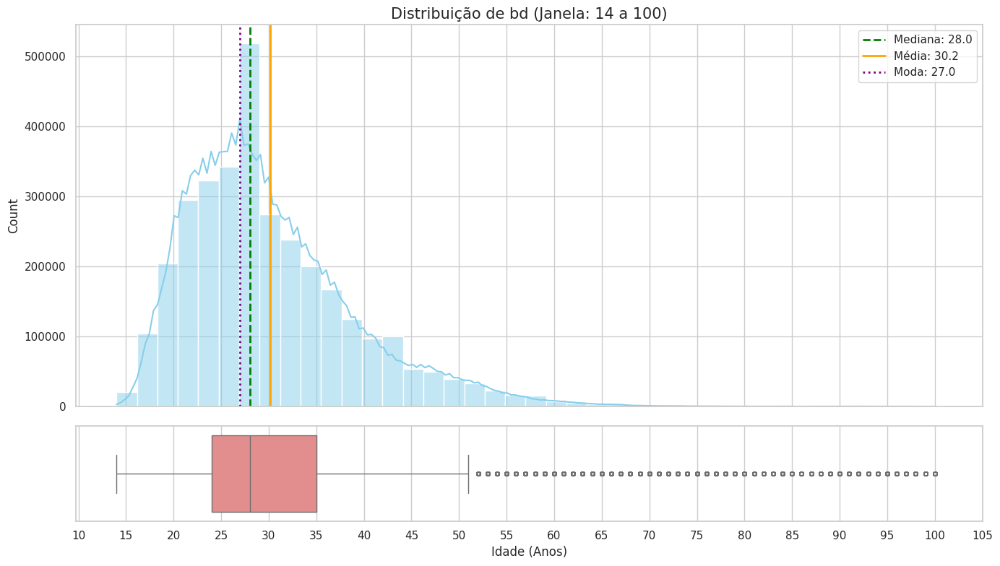

In [ ]:
df_age = df_age_pyspark.toPandas()


def plot_distribuicao_idade(
    df,
    col="bd",
    limite_min=None,
    limite_max=None
):
    temp_df = df.copy()

    # Garantir que a coluna seja numérica
    temp_df[col] = pd.to_numeric(temp_df[col], errors="coerce")

    # Remover nulos
    temp_df = temp_df.dropna(subset=[col])

    # Aplicar limites
    if limite_min is not None:
        temp_df = temp_df[temp_df[col] >= limite_min]

    if limite_max is not None:
        temp_df = temp_df[temp_df[col] <= limite_max]

    # Estatísticas
    mediana = temp_df[col].median()
    media = temp_df[col].mean()

    moda_series = temp_df[col].mode()
    moda = moda_series.iloc[0] if not moda_series.empty else None

    min_val = temp_df[col].min()
    max_val = temp_df[col].max()

    # Gráfico
    sns.set_theme(style="whitegrid")

    fig, (ax_hist, ax_box) = plt.subplots(
        2,
        1,
        figsize=(14, 8),
        sharex=True,
        gridspec_kw={"height_ratios": (.8, .2)}
    )

    sns.histplot(
        data=temp_df,
        x=col,
        kde=True,
        ax=ax_hist,
        color="skyblue",
        bins=40
    )

    ax_hist.set_title(
        f"Distribuição de {col} "
        f"(Janela: {min_val:.0f} a {max_val:.0f})",
        fontsize=15
    )

    ax_hist.axvline(
        mediana,
        color="green",
        linestyle="--",
        linewidth=2,
        label=f"Mediana: {mediana:.1f}"
    )

    ax_hist.axvline(
        media,
        color="orange",
        linestyle="-",
        linewidth=2,
        label=f"Média: {media:.1f}"
    )

    if moda is not None:
        ax_hist.axvline(
            moda,
            color="purple",
            linestyle=":",
            linewidth=2,
            label=f"Moda: {moda:.1f}"
        )

    ax_hist.legend()

    sns.boxplot(
        data=temp_df,
        x=col,
        ax=ax_box,
        color="lightcoral",
        fliersize=4
    )

    ax_box.set_xlabel("Idade (Anos)", fontsize=12)

    # Eixo X de 5 em 5 anos
    start = int(min_val // 5 * 5)
    end = int(max_val // 5 * 5) + 10

    ticks = np.arange(start, end, 5)
    plt.xticks(ticks)

    plt.tight_layout()
    plt.show()


plot_distribuicao_idade(
    df_age,
    limite_min=14,
    limite_max=100
)

In [ ]:
# Aplicar valores absolutos à coluna 'bd' em dfs_members
# Também garantir que seja do tipo inteiro, como geralmente é esperado para idade.
df_age_analysis = df_age_analysis.withColumn("bd", F.abs(F.col("bd")).cast("int"))

print("Coluna 'bd' em dfs_members convertida para valores absolutos (idade).")

Coluna 'bd' em dfs_members convertida para valores absolutos (idade).


In [ ]:
df_age_analysis.limit(10).show()

+--------------------+---+-----------------+
|                msno| bd|     idade_status|
+--------------------+---+-----------------+
|+2vC1rM36Emx77Uan...|  0|INVALIDA_MENOR_12|
|+BauTESekzh7dOwBq...| 26|           VALIDA|
|+Ee3Z6oRlCNX6Kf4v...| 28|           VALIDA|
|+JHf/MffV4y3kezHL...|  0|INVALIDA_MENOR_12|
|+OoOiHJRcSa7hWlhb...| 24|           VALIDA|
|+SieD5RhNkErwWzDK...|  0|INVALIDA_MENOR_12|
|+SowIRBgloTOSvXzC...| 28|           VALIDA|
|+eBaZiWiWUXOsCCt/...|  0|INVALIDA_MENOR_12|
|+fay303FtaFanbqYJ...|  0|INVALIDA_MENOR_12|
|/0g0PK2PDiikfoR7+...|  0|INVALIDA_MENOR_12|
+--------------------+---+-----------------+



In [ ]:
# Determinando os Limites Inferiores e superiores
pdf_age_filtered = df_age_analysis.toPandas()
#pdf_age[pdf_age['bd'] > 14]

# 2. Cálculo das métricas estatísticas baseadas na população real (> 14)
Q1 = pdf_age_filtered['bd'].quantile(0.25)
Q3 = pdf_age_filtered['bd'].quantile(0.75)
IQR = Q3 - Q1

# Agora os limites serão fidedignos à massa principal
limite_inferior_estatistico = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# 3. Classificação (aplicada ao pdf_age ORIGINAL para ver o impacto total)
total_geral = len(pdf_age)

outliers_sup = pdf_age[pdf_age['age'] > limite_superior]
abaixo_piso = pdf_age[pdf_age['age'] <= 14] # O que você quer tratar
dentro_limite = pdf_age[(pdf_age['age'] > 14) & (pdf_age['age'] <= limite_superior)]

# 4. Exibição do Resumo
resumo_dados = {
    "Categoria": ["Dentro do Limite (>14)", "Outliers Superiores", "Ruído/Piso (<=14)"],
    "Qtd": [len(dentro_limite), len(outliers_sup), len(abaixo_piso)],
}

print("======================================================")
print(f"📊 ANÁLISE COM FOCO EM POPULAÇÃO REAL (Total: {total_geral:,})")
print("======================================================")
for i in range(len(resumo_dados["Categoria"])):
    cat = resumo_dados["Categoria"][i]
    qtd = resumo_dados["Qtd"][i]
    perc = (qtd / total_geral) * 100
    print(f"{cat:<25} | {qtd:<10,} | {perc:>6.2f}%")
print("------------------------------------------------------")
print(f"L. Superior Real: {limite_superior:.2f}")
print(f"L. Inferior Estatístico (Ref): {limite_inferior_estatistico:.2f}")
print("======================================================\n")

📊 ANÁLISE COM FOCO EM POPULAÇÃO REAL (Total: 1,166,116)
Dentro do Limite (>14)    | 635,069    |  54.46%
Outliers Superiores       | 1,438      |   0.12%
Ruído/Piso (<=14)         | 529,609    |  45.42%
------------------------------------------------------
L. Superior Real: 72.50
L. Inferior Estatístico (Ref): -43.50



In [ ]:
pdf_age = df_age_analysis.toPandas()

total_base = len(pdf_age)

qtd_zero = len(
    pdf_age[pdf_age["bd"] == 0]
)

qtd_1_a_13 = len(
    pdf_age[
        (pdf_age["bd"] > 0) &
        (pdf_age["bd"] < 14)
    ]
)

qtd_ate_13 = len(
    pdf_age[pdf_age["bd"] < 14]
)

pdf_age_referencia = pdf_age[
    pdf_age["bd"] >= 14
].copy()


Q1 = pdf_age_referencia["bd"].quantile(0.25)
Q3 = pdf_age_referencia["bd"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior_estatistico = Q1 - 1.5 * IQR
limite_superior_estatistico = Q3 + 1.5 * IQR

qtd_outlier_inferior = len(
    pdf_age[
        (pdf_age["bd"] >= 14) &
        (pdf_age["bd"] < limite_inferior_estatistico)
    ]
)

qtd_outlier_superior = len(
    pdf_age[
        pdf_age["bd"] > limite_superior_estatistico
    ]
)


df_regulares = pdf_age[
    (pdf_age["bd"] >= 14) &
    (pdf_age["bd"] >= limite_inferior_estatistico) &
    (pdf_age["bd"] <= limite_superior_estatistico)
].copy()

qtd_regular = len(df_regulares)

mediana_regular = df_regulares["bd"].median()

qtd_imputacao = (
    qtd_zero +
    qtd_1_a_13 +
    qtd_outlier_inferior +
    qtd_outlier_superior
)

diagnostico = [
    ["Idade = 0 (Não preenchido)", qtd_zero],
    ["Idade entre 1 e 13 (Inconsistente)", qtd_1_a_13],
    [
        "Outliers inferiores (< {:.1f})".format(
            limite_inferior_estatistico
        ),
        qtd_outlier_inferior
    ],
    [
        "Outliers superiores (> {:.1f})".format(
            limite_superior_estatistico
        ),
        qtd_outlier_superior
    ],
    [
        "Dados regulares ({:.1f} a {:.1f})".format(
            limite_inferior_estatistico,
            limite_superior_estatistico
        ),
        qtd_regular
    ]
]


print("==============================================================")
print(f"🔍 DIAGNÓSTICO DE IDADE - TOTAL: {total_base:,}")
print("==============================================================")
print(
    f"{'Categoria':<45} | "
    f"{'Qtd':>12} | "
    f"{'% Base':>8}"
)
print("-" * 75)

for cat, qtd in diagnostico:
    perc = (qtd / total_base) * 100

    print(
        f"{cat:<45} | "
        f"{qtd:>12,} | "
        f"{perc:>7.2f}%"
    )

print("-" * 75)

print(f"Q1:                          {Q1:.2f}")
print(f"Q3:                          {Q3:.2f}")
print(f"IQR:                         {IQR:.2f}")
print(f"Limite inferior estatístico: {limite_inferior_estatistico:.2f}")
print(f"Limite superior estatístico: {limite_superior_estatistico:.2f}")
print(f"Mediana regular:             {mediana_regular:.2f}")

print(
    f"Total para imputação:        "
    f"{qtd_imputacao:,} "
    f"({(qtd_imputacao / total_base) * 100:.2f}%)"
)

print("==============================================================")

🔍 DIAGNÓSTICO DE IDADE - TOTAL: 1,166,116
Categoria                                     |          Qtd |   % Base
---------------------------------------------------------------------------
Idade = 0 (Não preenchido)                    |      528,899 |   45.36%
Idade entre 1 e 13 (Inconsistente)            |          426 |    0.04%
Outliers inferiores (< 6.5)                   |            0 |    0.00%
Outliers superiores (> 50.5)                  |       20,593 |    1.77%
Dados regulares (6.5 a 50.5)                  |      616,198 |   52.84%
---------------------------------------------------------------------------
Q1:                          23.00
Q3:                          34.00
IQR:                         11.00
Limite inferior estatístico: 6.50
Limite superior estatístico: 50.50
Mediana regular:             28.00
Total para imputação:        549,918 (47.16%)


In [ ]:
# 1. Agrupamento por Safra
# Usar dfs_members, que é um PySpark DataFrame e contém 'safra', 'msno' e 'bd'.
# Aplicar a limpeza de 'bd' (absoluto e inteiro) consistentemente.
df_volumetria_safra = dfs_members.filter((F.abs(F.col("bd")).cast("int") > 14) & (F.abs(F.col("bd")).cast("int") <= 100)).groupBy("safra").agg(
    F.countDistinct("msno").alias("qtd_usuarios_unicos"),
    F.avg(F.abs(F.col("bd")).cast("int")).alias("media_idade_tratada"),
    F.min(F.abs(F.col("bd")).cast("int")).alias("min_idade_bruta"),
    F.max(F.abs(F.col("bd")).cast("int")).alias("max_idade_bruta")
).orderBy("safra")

# 2. Exibição dos resultados
print("📊 Volumetria e Saúde dos Dados por Safra")
df_volumetria_safra.show()

# 3. Converter para Pandas para uma visualização rápida de tendência (opcional)
pdf_volumetria = df_volumetria_safra.toPandas()

📊 Volumetria e Saúde dos Dados por Safra
+------+-------------------+-------------------+---------------+---------------+
| safra|qtd_usuarios_unicos|media_idade_tratada|min_idade_bruta|max_idade_bruta|
+------+-------------------+-------------------+---------------+---------------+
|201601|             501962|  30.39994461732163|             15|            100|
|201602|             514498| 30.289390823676673|             15|            100|
|201603|             459465| 30.118838214009774|             15|            100|
|201604|             429183| 30.274593821283695|             15|            100|
|201605|             434211|  30.02628215314674|             15|            100|
|201606|             420488|  30.17616436140865|             15|            100|
|201607|             499698|  29.96619758334034|             15|            100|
|201608|             495077|  30.08239526376705|             15|            100|
|201609|             492448|  30.03818677301969|             15|    

### Registrado VIA ...

In [ ]:
# Verificar se um cliente possui mais de um 'registered_via'
print("Clientes com mais de um 'registered_via' registrado:")
clientes_multi_registered_via = dfs_members.groupBy("msno").agg(
    F.countDistinct("registered_via").alias("qtd_registered_via"),
    F.collect_set("registered_via").alias("registered_vias_registrados")
).filter(F.col("qtd_registered_via") > 1)

if clientes_multi_registered_via.count() > 0:
    clientes_multi_registered_via.show(truncate=False)
else:
    print("Nenhum cliente foi encontrado com múltiplos 'registered_via' registrados.")

Clientes com mais de um 'registered_via' registrado:
Nenhum cliente foi encontrado com múltiplos 'registered_via' registrados.


In [ ]:
print("### Análise da coluna 'registered_via'\n")
# 1. Distribuição de Clientes por 'registered_via'
print("#### Distribuição de Clientes Únicos por 'Registered Via'")
df_registered_via_pyspark = (
    dfs_members.filter(F.col('dataset_type') == 'train')
    .groupBy("registered_via")
    .agg(F.countDistinct("msno").alias("clientes_unicos"))
    .orderBy(F.asc("registered_via"))
)

df_registered_via_pyspark.show()

# Converter para Pandas para plotagem
df_registered_via = df_registered_via_pyspark.toPandas()

# Criar o gráfico de barras com Plotly
fig = go.Figure()

fig.add_trace(go.Bar(
    x=df_registered_via['registered_via'].astype(str), # Converte para string para o eixo X
    y=df_registered_via['clientes_unicos'],
    text=df_registered_via['clientes_unicos'],  # Mostra o valor em cima da barra
    textposition='auto',
    texttemplate='%{text:,.0f}',       # Formata o texto da barra com separador de milhar
    marker_color='#FF97FF',             # Cor roxa/rosa para diferenciar
    hovertemplate="<b>Registered Via:</b> %{x}<br><b>Clientes:</b> %{y:,.0f}<extra></extra>"
))

# Personalização do Layout
fig.update_layout(
    title={
        'text': "Distribuição de Clientes Únicos por 'Registered Via'",
        'y': 0.95,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    xaxis_title="Tipo de Registro (Registered Via)",
    yaxis_title="Quantidade de Clientes (msno)",
    template="plotly_white",
    width=900,
    height=500
)

# Garante que o eixo X trate os tipos de registro como categorias discretas
fig.update_xaxes(type='category')

# Exibe o gráfico
fig.show()

### Análise da coluna 'registered_via'

#### Distribuição de Clientes Únicos por 'Registered Via'
+--------------+---------------+
|registered_via|clientes_unicos|
+--------------+---------------+
|            10|              1|
|             3|         200198|
|             4|          67189|
|             7|         484220|
|             9|         414508|
+--------------+---------------+



In [ ]:
print("### Análise da coluna 'registered_via'\n")
print("#### Distribuição de Clientes Únicos por 'registered_via'")

df_registered_via = (
    dfs_members
    .filter(F.col("dataset_type") == "train")
    .groupBy("registered_via")
    .agg(
        F.countDistinct("msno").alias("clientes_unicos")
    )
    .orderBy(F.asc("registered_via"))
)

df_registered_via.show(truncate=False)

print("\n#### Churn por 'registered_via'")

df_registered_via_churn = (
    dfs_members
    .filter(F.col("dataset_type") == "train")
    .groupBy("registered_via")
    .agg(
        # clientes únicos
        F.countDistinct("msno").alias("clientes_unicos"),

        # clientes que tiveram churn
        F.countDistinct(
            F.when(F.col("churn_m3") == 1, F.col("msno"))
        ).alias("clientes_churn"),

        # quantidade de observações churn
        F.sum("churn_m3").alias("qtd_churn"),

        # taxa de churn das observações
        F.avg("churn_m3").alias("taxa_churn")
    )
    .withColumn(
        "taxa_churn_pct",
        F.round(F.col("taxa_churn") * 100, 3)
    )
    .withColumn(
        "pct_clientes",
        F.round(
            F.col("clientes_unicos") /
            F.sum("clientes_unicos").over(
                Window.partitionBy()
            ) * 100,
            2
        )
    )
    .orderBy(F.asc("registered_via"))
)

df_registered_via_churn.show(truncate=False)

### Análise da coluna 'registered_via'

#### Distribuição de Clientes Únicos por 'registered_via'
+--------------+---------------+
|registered_via|clientes_unicos|
+--------------+---------------+
|10            |1              |
|3             |200198         |
|4             |67189          |
|7             |484220         |
|9             |414508         |
+--------------+---------------+


#### Churn por 'registered_via'
+--------------+---------------+--------------+---------+-------------------+--------------+------------+
|registered_via|clientes_unicos|clientes_churn|qtd_churn|taxa_churn         |taxa_churn_pct|pct_clientes|
+--------------+---------------+--------------+---------+-------------------+--------------+------------+
|10            |1              |1             |1        |1.0                |100.0         |0.0         |
|3             |200198         |113230        |224348   |0.23929789680499527|23.93         |17.17       |
|4             |67189          |38023    